In [1]:
using CSV, DataFrames

In [2]:
df = CSV.read("kenyadata.csv", DataFrame)
df = df[1:end-1, :]

Row,County,Public Schools,Private Schools,Total School,Enrollment in Public Schools,Enrollment in Private Schools,Avg School Size,Gross Enrollment,Net Enrollment,Total Enrollment,Population
,String15,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Int64,Float64
1,Mombasa,50,79,129,28317,9306,292,46.7,31.0,37623,80563.2
2,Kwale,91,10,101,42886,1562,440,51.9,26.5,44448,85641.6
3,Kilifi,159,41,200,81917,7647,448,59.9,30.9,89564,1.49523e5
4,Tana River,33,2,35,9818,374,291,34.3,18.9,10192,29714.3
5,Lamu,27,4,31,8145,357,274,64.7,35.4,8502,13140.6
6,Taita Taveta,87,7,94,29254,643,318,98.6,68.0,29897,30321.5
7,Garissa,35,33,68,13931,7341,313,20.5,9.9,21272,1.03766e5
8,Wajir,53,3,56,21586,228,390,23.3,14.5,21814,93622.3
9,Mandera,57,8,65,18613,434,293,18.7,11.4,19047,1.01856e5


In [3]:
using JuMP
using Gurobi

n = nrow(df)

total_student = df[!, "Total Enrollment"]
school_age_pop = df[!, "Population"]
avg_class_size = df[!, "Avg School Size"]

model = Model(Gurobi.Optimizer)
@variable(model, x[1:n] ≥ 0, Int)
@variable(model, z)
@variable(model, maxZ)

@constraints model begin
    sum((x[i]) for i in 1:n) * 500000 <= 200000000
    [i in 1:n], z <= (total_student[i]+ avg_class_size[i]*x[i])/school_age_pop[i]

    #playing around
    #[i in 1:8], x[i] >= 1
end
@objective(model, Max, z)
optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2621328
Academic license - for non-commercial use only - expires 2026-02-12
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[x86] - Darwin 21.6.0 21G1974)

CPU model: Intel(R) Core(TM) i5-8257U CPU @ 1.40GHz
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 48 rows, 49 columns and 141 nonzeros
Model fingerprint: 0x9dde0c80
Coefficient statistics:
  Matrix range     [1e-03, 5e+05]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-01, 2e+08]
Presolve removed 19 rows and 20 columns
Presolve time: 0.00s
Presolved: 29 rows, 29 columns, 84 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      11    4.5088709e-01   0.000000e+00   0.000000e+00      0s

Solved in 11 iterations and 0.00 seconds (0.00 work units)
Optimal objective  4.508870896e-01

User-call

In [4]:
println("Min Schools: ", objective_value(model))
#println("Optimal Z value: ", value(Z))
addedstudents = 0
for i in 1:n
    #println(df[!,"County"][i],": ", value(x[i]),"  ",  (total_student[i]+ avg_class_size[i]*value(x[i]))/school_age_pop[i])
    println(df[!,"County"][i],": ", value(x[i]))
    addedstudents = addedstudents + value(x[i])*avg_class_size[i]
end
df.schools_added = value.(x)
df.final_percent = [100*(total_student[i] + avg_class_size[i]*value(x[i])) / school_age_pop[i] for i in 1:n]

Min Schools: 0.4508870895541814
: 0.0sa
Kwale: 0.0
Kilifi: 0.0
Tana River: 11.01645292770894
Lamu: 0.0
Taita Taveta: 0.0
Garissa: 81.5165615651693
Wajir: 52.30536999995182
Mandera: 91.73509147474819
Marsabit: 62.51947479630864
Isiolo: 22.557766398276065
Meru: 0.0
Tharaka: 0.0
Embu: 0.0
Kitui: 0.0
Machakos: 0.0
Makueni: 0.0
Nyandarua: 0.0
Nyeri: 0.0
Kirinyaga: 0.0
Murang'a: 0.0
Kiambu: 0.0
Turkana: 20.35568850342413
West Pokot: 0.0
Samburu: 6.324191525799689
Trans Nzoia: 0.0
Uasin Gishu: 0.0
Keiyo-Marakwet: 0.0
Nandi: 0.0
Baringo: 0.0
Laikipia: 0.0
Nakuru: 0.0
Narok: 0.0
Kajiado: 0.0
Kericho: 0.0
Bomet: 0.0
Kakamega: 0.0
Vihiga: 0.0
Bungoma: 0.0
Busia: 0.0
Siaya: 0.0
Kisumu: 0.0
Homa Bay: 0.0
Migori: 0.0
Kisii: 0.0
Nyamira: 0.0
Nairobi: 51.6694028086132


47-element Vector{Float64}:
  46.70000000283007
  51.89999999824852
  59.89999998501898
  45.08870895541814
  64.69999999961951
  98.60000001365368
  45.08870895541815
  45.08870895541814
  45.088708955418134
  45.08870895541814
  45.08870895541814
  86.49999998421445
 135.99999998516526
   ⋮
  98.69999999985843
  86.20000001109312
 115.50000000790013
  86.79999999472658
  68.29999996772762
  99.90000003063729
  85.09999998335151
  92.8999999867446
  83.20000002104894
 103.6999999626609
  98.19999999773556
  45.08870895541811

In [5]:
increase = addedstudents/sum(school_age_pop)

0.02690348716394419

In [6]:
df

Row,County,Public Schools,Private Schools,Total School,Enrollment in Public Schools,Enrollment in Private Schools,Avg School Size,Gross Enrollment,Net Enrollment,Total Enrollment,Population,schools_added,final_percent
,String15,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Int64,Float64,Float64,Float64
1,Mombasa,50,79,129,28317,9306,292,46.7,31.0,37623,80563.2,0.0,46.7
2,Kwale,91,10,101,42886,1562,440,51.9,26.5,44448,85641.6,0.0,51.9
3,Kilifi,159,41,200,81917,7647,448,59.9,30.9,89564,1.49523e5,0.0,59.9
4,Tana River,33,2,35,9818,374,291,34.3,18.9,10192,29714.3,11.0165,45.0887
5,Lamu,27,4,31,8145,357,274,64.7,35.4,8502,13140.6,0.0,64.7
6,Taita Taveta,87,7,94,29254,643,318,98.6,68.0,29897,30321.5,0.0,98.6
7,Garissa,35,33,68,13931,7341,313,20.5,9.9,21272,1.03766e5,81.5166,45.0887
8,Wajir,53,3,56,21586,228,390,23.3,14.5,21814,93622.3,52.3054,45.0887
9,Mandera,57,8,65,18613,434,293,18.7,11.4,19047,1.01856e5,91.7351,45.0887


In [7]:
CSV.write("mydata.csv", df)

"mydata.csv"

In [34]:

# Load properly (real header starts at row 5)
gdp = CSV.read("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_19346.csv", DataFrame; header=5)
enrollment = CSV.read("API_SE.SEC.ENRR_DS2_en_csv_v2_21351.csv", DataFrame; header=5)

# Select needed columns
gdp_selected = select(gdp, ["Country Name", "Country Code", "2020"])
enrollment_selected = select(enrollment, ["Country Name", "Country Code", "2020"])

# Only fix commas and parse if the column is made of Strings
if eltype(gdp_selected[!, "2020"]) <: AbstractString
    gdp_selected[!, "2020"] = parse.(Float64, replace.(gdp_selected[!, "2020"], "," => ""))
end

if eltype(enrollment_selected[!, "2020"]) <: AbstractString
    enrollment_selected[!, "2020"] = parse.(Float64, replace.(enrollment_selected[!, "2020"], "," => ""))
end


# Rename columns to avoid confusion
rename!(gdp_selected, "2020" => "GDP_2020")
rename!(enrollment_selected, "2020" => "Enrollment_2020")

# Let's check how much missing data exists before we join
println("GDP rows with missing 2020: ", count(ismissing, gdp_selected.GDP_2020))
println("Enrollment rows with missing 2020: ", count(ismissing, enrollment_selected.Enrollment_2020))

# Drop rows missing 2020 data BEFORE joining
gdp_clean = dropmissing(gdp_selected, :GDP_2020)
enrollment_clean = dropmissing(enrollment_selected, :Enrollment_2020)

# Now do the join (only between valid countries)
combined = innerjoin(gdp_clean, enrollment_clean, on="Country Code", makeunique=true)

# Final cleaned table
println("Number of matched countries: ", nrow(combined))
println(combined)


GDP rows with missing 2020: 8
Enrollment rows with missing 2020: 78
Number of matched countries: 187
187×5 DataFrame
 Row │ Country Name                       Country Code  GDP_2020       Country Name_1                     Enrollment_2020 
     │ String                             String3       Float64        String                             Float64         
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Aruba                              ABW           22855.9        Aruba                                     132.908
   2 │ Africa Eastern and Southern        AFE            1344.08       Africa Eastern and Southern                43.6888
   3 │ Africa Western and Central         AFW            1664.25       Africa Western and Central                 45.6518
   4 │ Albania                            ALB            5370.78       Albania                                    95.9295
   5 │ Andorra             

210.008139902508


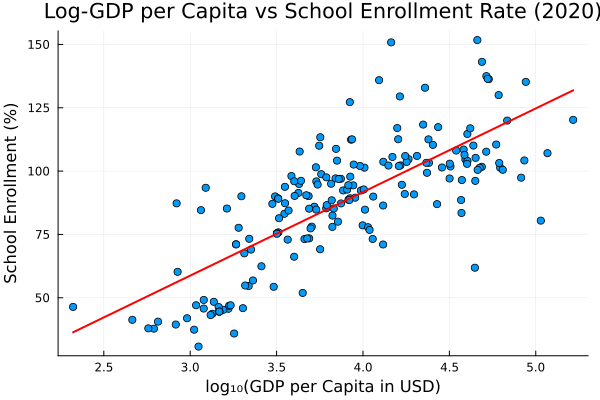

In [35]:
using GLM
using Plots

# Step 1: Inspect GDP per capita values
println(minimum(combined.GDP_2020))  # Replace with your actual column name

# Step 2: Filter out invalid or zero GDPpc
combined = filter(:GDP_2020 => x -> x > 0, combined)

# Step 3: Add logGDPpc column
combined.logGDPpc = log10.(combined.GDP_2020)


model = lm(@formula(Enrollment_2020 ~ logGDPpc), combined)

scatter(combined.logGDPpc, combined.Enrollment_2020,
    xlabel="log₁₀(GDP per Capita in USD)",
    ylabel="School Enrollment (%)",
    title="Log-GDP per Capita vs School Enrollment Rate (2020)",
    legend=false)



x_vals = range(minimum(combined.logGDPpc), stop=maximum(combined.logGDPpc), length=100)
y_vals = coef(model)[1] .+ coef(model)[2] .* x_vals
plot!(x_vals, y_vals, lw=2, linecolor=:red)



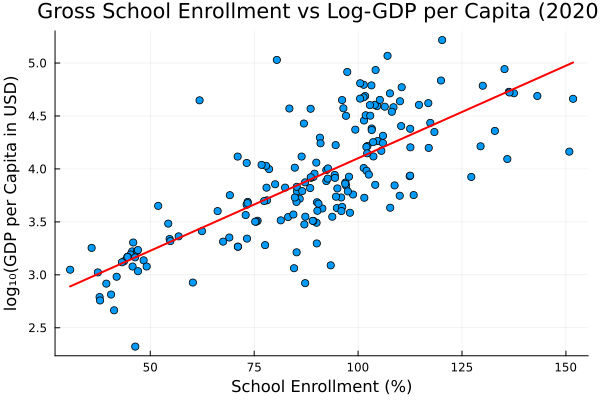

In [36]:
scatter(combined.Enrollment_2020, combined.logGDPpc,
    xlabel="School Enrollment (%)",
    ylabel="log₁₀(GDP per Capita in USD)",
    title="Gross School Enrollment vs Log-GDP per Capita (2020)",
    legend=false)

# Fit new regression model with enrollment as predictor
model_swapped = lm(@formula(logGDPpc ~ Enrollment_2020), combined)

# Regression line
x_vals = range(minimum(combined.Enrollment_2020), stop=maximum(combined.Enrollment_2020), length=100)
y_vals = coef(model_swapped)[1] .+ coef(model_swapped)[2] .* x_vals
plot!(x_vals, y_vals, lw=2, linecolor=:red)


In [38]:
coef(model_swapped)[2]

0.017472528752535625